In [237]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import joblib
import os

In [238]:
landmark_path = "D:\\IDE Repo\\Dl-net\\data\\casme2-preprocessed-v2\\face_landmarks.csv"   
train_path = "D:\\IDE Repo\\Dl-net\\data\\casme2-preprocessed-v2\\train.csv" 
SAVE_DIR = "processed"
os.makedirs(SAVE_DIR, exist_ok=True)

In [239]:
landmarks_df = pd.read_csv(landmark_path)
train_df = pd.read_csv(train_path)
print("=" * 60)
print("Landmarks Dataset")
print(landmarks_df.shape)
print("=" * 60)
print("Train Dataset")
print(train_df.shape)
landmarks_df.head()


Landmarks Dataset
(500, 1436)
Train Dataset
(13615, 14)


,filepath,landmarks_detected,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,...,z_474,x_475,y_475,z_475,x_476,y_476,z_476,x_477,y_477,z_477
0,./data/casme2-preprocessed-v2\CASME2 Preproces...,478,0.514768,0.722219,-0.136648,0.523118,0.576818,-0.294961,0.517824,0.617790,...,0.025961,0.768488,0.236143,0.025960,0.713368,0.271990,0.025894,0.768613,0.307834,0.025907
1,./data/casme2-preprocessed-v2\CASME2 Preproces...,478,0.503075,0.703677,-0.148351,0.493394,0.541940,-0.285421,0.497619,0.590272,...,0.017879,0.768665,0.234639,0.017880,0.715009,0.270061,0.017815,0.770119,0.305565,0.017829
2,./data/casme2-preprocessed-v2\CASME2 Preproces...,478,0.500352,0.686904,-0.110848,0.499011,0.567026,-0.270116,0.498298,0.594931,...,0.000029,0.764490,0.239815,0.000024,0.711010,0.275667,-0.000036,0.763916,0.310359,-0.000028
3,./data/casme2-preprocessed-v2\CASME2 Preproces...,478,0.501748,0.691448,-0.144714,0.504308,0.553497,-0.295761,0.501742,0.600460,...,0.034370,0.796956,0.252263,0.034371,0.740294,0.285858,0.034301,0.794857,0.321623,0.034317
4,./data/casme2-preprocessed-v2\CASME2 Preproces...,478,0.485267,0.679308,-0.135492,0.496794,0.537978,-0.274870,0.493410,0.576039,...,0.013004,0.766617,0.254572,0.013000,0.715819,0.286032,0.012945,0.764681,0.318232,0.012957


In [240]:
train_df.head()

,filepath,extension,width,height,resolution,mode,aspect_ratio,brightness,contrast,sharpness,edge_density,entropy,noise,class
0,./data/casme2-preprocessed-v2/CASME2 Preproces...,.jpg,259,308,79772,RGB,0.841,90.150930,36.217449,59.012542,0.010492,7.070181,92.900850,surprise
1,./data/casme2-preprocessed-v2/CASME2 Preproces...,.jpg,259,313,81067,RGB,0.827,113.415163,37.030567,34.598467,0.005847,7.131897,100.353917,disgust
2,./data/casme2-preprocessed-v2/CASME2 Preproces...,.jpg,263,315,82845,RGB,0.835,84.742664,29.501137,28.869772,0.008896,6.793766,88.410561,disgust
3,./data/casme2-preprocessed-v2/CASME2 Preproces...,.jpg,284,321,91164,RGB,0.885,95.845882,40.332515,39.903049,0.010969,6.938547,93.265230,happy
4,./data/casme2-preprocessed-v2/CASME2 Preproces...,.jpg,256,312,79872,RGB,0.821,114.856971,36.516864,44.872642,0.008075,7.082653,103.252668,disgust


In [241]:
print('landmarks filepath sample:')
print(landmarks_df['filepath'].head(10).to_string(index=False))
print('\ntrain filepath sample:')
print(train_df['filepath'].head(10).to_string(index=False))
print('\nlandmarks basename sample:')
landmarks_df['filepath'] = landmarks_df['filepath'].str.replace('\\', '/', regex=False)
print(landmarks_df['filepath'].head(10).to_string(index=False))
print('\ntrain basename sample:')
train_df['filepath'] = train_df['filepath'].str.replace('\\', '/', regex=False)
print(train_df['filepath'].str.split('/').str[-1].head(10).to_string(index=False))

landmarks filepath sample:
./data/casme2-preprocessed-v2\CASME2 Preprocess...
./data/casme2-preprocessed-v2\CASME2 Preprocess...
./data/casme2-preprocessed-v2\CASME2 Preprocess...
./data/casme2-preprocessed-v2\CASME2 Preprocess...
./data/casme2-preprocessed-v2\CASME2 Preprocess...
./data/casme2-preprocessed-v2\CASME2 Preprocess...
./data/casme2-preprocessed-v2\CASME2 Preprocess...
./data/casme2-preprocessed-v2\CASME2 Preprocess...
./data/casme2-preprocessed-v2\CASME2 Preprocess...
./data/casme2-preprocessed-v2\CASME2 Preprocess...

train filepath sample:
./data/casme2-preprocessed-v2/CASME2 Preprocess...
./data/casme2-preprocessed-v2/CASME2 Preprocess...
./data/casme2-preprocessed-v2/CASME2 Preprocess...
./data/casme2-preprocessed-v2/CASME2 Preprocess...
./data/casme2-preprocessed-v2/CASME2 Preprocess...
./data/casme2-preprocessed-v2/CASME2 Preprocess...
./data/casme2-preprocessed-v2/CASME2 Preprocess...
./data/casme2-preprocessed-v2/CASME2 Preprocess...
./data/casme2-preprocessed-v2/C

In [242]:
# Data from train.csv
label_column = "class"

# Landmark columns from face_landmarks.csv
x_cols = sorted(
    [c for c in landmarks_df.columns if c.startswith("x_")],
    key=lambda x: int(x.split("_")[1]),
)
y_cols = sorted(
    [c for c in landmarks_df.columns if c.startswith("y_")],
    key=lambda x: int(x.split("_")[1]),
)
z_cols = sorted(
    [c for c in landmarks_df.columns if c.startswith("z_")],
    key=lambda x: int(x.split("_")[1]),
)

print("Number of X landmarks:", len(x_cols))
print("Number of Y landmarks:", len(y_cols))
print("Number of Z landmarks:", len(z_cols))

Number of X landmarks: 478
Number of Y landmarks: 478
Number of Z landmarks: 478


In [243]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import os

datasets = [
    {
        "name": "casme2",
        "landmark": "D:\\IDE Repo\\Dl-net\\data\\casme2-preprocessed-v2\\face_landmarks.csv",
        "train": "D:\\IDE Repo\\Dl-net\\data\\casme2-preprocessed-v2\\train.csv",
    },
    {
        "name": "samm",
        "landmark": "D:\\IDE Repo\\Dl-net\\data\\sammassamexpression\\face_landmarks.csv",
        "train": "D:\\IDE Repo\\Dl-net\\data\\sammassamexpression\\train.csv",
    },
]

merged_list = []
label_column = "class"

for ds in datasets:
    if not (os.path.exists(ds["landmark"]) and os.path.exists(ds["train"])):
        print(f"Skipping {ds['name']} — files not found: {ds['landmark']} or {ds['train']}")
        continue

    ldf = pd.read_csv(ds["landmark"]).copy()
    tdf = pd.read_csv(ds["train"]).copy()

    # =========================================================
    # MISSING LINES ADDED BACK HERE: 
    # Create 'filepath_norm' so both DataFrames have matching keys
    # =========================================================
    ldf["filepath_norm"] = ldf["filepath"].astype(str).str.strip().str.replace("\\", "/", regex=False)
    tdf["filepath_norm"] = tdf["filepath"].astype(str).str.strip().str.replace("\\", "/", regex=False)
    
    # determine x/y/z cols in this landmark file
    x_cols_local = sorted([c for c in ldf.columns if c.startswith("x_")], key=lambda x: int(x.split("_")[1]))
    y_cols_local = sorted([c for c in ldf.columns if c.startswith("y_")], key=lambda x: int(x.split("_")[1]))
    z_cols_local = sorted([c for c in ldf.columns if c.startswith("z_")], key=lambda x: int(x.split("_")[1]))

    if len(x_cols_local) == 0 or len(y_cols_local) == 0:
        print(f"No x/y landmarks found for {ds['name']}, skipping")
        continue

    # Include z_cols_local so the 3D data isn't thrown away!
    use_cols = ["filepath_norm"] + x_cols_local + y_cols_local + z_cols_local
    ldf_sel = ldf[use_cols]

    merged = ldf_sel.merge(tdf[["filepath_norm", label_column]], on="filepath_norm", how="inner")
    print(f"{ds['name']} merged:", merged.shape)

    if merged.empty:
        print(f"Warning: no rows matched for {ds['name']}")
        continue

    merged_list.append(merged)

if not merged_list:
    raise RuntimeError("No dataset merged — check that data files exist and filepath columns match.")

# concatenate merged datasets
merged_all = pd.concat(merged_list, ignore_index=True)
print("Combined merged dataset:", merged_all.shape)

# Identify X, Y, and Z landmark columns
x_cols = sorted([c for c in merged_all.columns if c.startswith("x_")], key=lambda x: int(x.split("_")[1]))
y_cols = sorted([c for c in merged_all.columns if c.startswith("y_")], key=lambda x: int(x.split("_")[1]))
z_cols = sorted([c for c in merged_all.columns if c.startswith("z_")], key=lambda x: int(x.split("_")[1]))

# Ensure we have a matching number of coordinates
min_len = min(len(x_cols), len(y_cols), len(z_cols))
x_cols = x_cols[:min_len]
y_cols = y_cols[:min_len]
z_cols = z_cols[:min_len]

print(f"Using {min_len} 3D landmarks.")

# Build feature list keeping X, Y, AND Z together for each node
features = []
for i in range(min_len):
    features.extend([x_cols[i], y_cols[i], z_cols[i]])

# 1. Prepare Features and Labels
X = merged_all[features]

# Use filepath_norm to avoid KeyError
filepaths = merged_all['filepath_norm'].values 

encoder = LabelEncoder()
y = encoder.fit_transform(merged_all[label_column].astype(str).values.ravel())

# 2. Impute missing values
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=features)

# 3. Create Group IDs
def get_group_id(filepath):
    basename = os.path.basename(str(filepath).replace('\\', '/'))
    return basename.split(' (')[0].split('.')[0]

groups = [get_group_id(fp) for fp in filepaths]

# 4. Perform the Grouped Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

casme2 merged: (393, 1436)
samm merged: (395, 1436)
Combined merged dataset: (788, 1436)
Using 478 3D landmarks.
Train set shape: (626, 1434) (626,)
Test set shape: (162, 1434) (162,)


In [244]:
import re

# 1. Helper function to extract the base video name and frame number
# e.g., "reg_img44 (4).jpg" -> base: "reg_img44", frame: 4
def parse_filepath(fp):
    basename = os.path.basename(str(fp).replace('\\', '/'))
    base_split = basename.split(' (')
    
    video_name = base_split[0]
    frame_num = 0
    if len(base_split) > 1:
        # Extract the number inside the parentheses
        num_str = re.sub(r'[^0-9]', '', base_split[1])
        if num_str:
            frame_num = int(num_str)
            
    return video_name, frame_num

# 2. Extract Onset and Apex Features
# We assume 'merged_all' currently holds your APEX frames (from train.csv)
# We assume 'ldf' (the raw landmarks DataFrame) holds ALL frames.

onset_features_list = []
apex_features_list = []
valid_indices = []

print("Extracting Onset and Apex pairs...")
for idx, row in merged_all.iterrows():
    apex_fp = row['filepath_norm']
    video_name, apex_frame_num = parse_filepath(apex_fp)
    
    # Find all frames in the raw landmarks CSV that belong to this video
    video_frames = ldf[ldf['filepath_norm'].str.contains(video_name, na=False)]
    
    if video_frames.empty:
        continue
        
    # Find the frame with the lowest frame number (The Onset / Neutral frame)
    # We apply our parse function to sort them
    video_frames['frame_num'] = video_frames['filepath_norm'].apply(lambda x: parse_filepath(x)[1])
    onset_row = video_frames.loc[video_frames['frame_num'].idxmin()]
    
    # Extract the 3D features (using your previously defined 'features' list of X,Y,Z columns)
    onset_feats = onset_row[features].values.astype(np.float32)
    apex_feats = row[features].values.astype(np.float32)
    
    onset_features_list.append(onset_feats)
    apex_features_list.append(apex_feats)
    valid_indices.append(idx)

# 3. Create our new matched DataFrames
X_onset = pd.DataFrame(onset_features_list, columns=features)
X_apex = pd.DataFrame(apex_features_list, columns=features)
y_temporal = y[valid_indices]
groups_temporal = np.array(groups)[valid_indices]

# 4. Grouped Split on the new matched data
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_apex, y_temporal, groups_temporal))

X_onset_train, X_onset_test = X_onset.iloc[train_idx], X_onset.iloc[test_idx]
X_apex_train, X_apex_test = X_apex.iloc[train_idx], X_apex.iloc[test_idx]
y_train, y_test = y_temporal[train_idx], y_temporal[test_idx]

print("Temporal Train set shape:", X_apex_train.shape)
print("Temporal Test set shape:", X_apex_test.shape)

Extracting Onset and Apex pairs...
Temporal Train set shape: (315, 1434)
Temporal Test set shape: (80, 1434)


In [245]:
def create_temporal_graph_dataset(X_apex, X_onset, y, edge_index):
    X_apex_np = X_apex.values if hasattr(X_apex, "values") else np.asarray(X_apex)
    X_onset_np = X_onset.values if hasattr(X_onset, "values") else np.asarray(X_onset)
    
    dataset = []
    num_nodes = 478 # Standard MediaPipe Face Mesh

    for i in range(len(X_apex_np)):
        # Reshape to (478, 3) for X, Y, Z
        apex_coords = X_apex_np[i].reshape(num_nodes, 3).astype(np.float32)
        onset_coords = X_onset_np[i].reshape(num_nodes, 3).astype(np.float32)

        # --- 1. Calculate Temporal Displacement (Velocity) ---
        # Delta = Peak - Neutral
        displacement = apex_coords - onset_coords

        # --- 2. Inter-Ocular Normalization ---
        # MediaPipe Iris Centers: Left=468, Right=473
        eye_l = onset_coords[468, :3]
        eye_r = onset_coords[473, :3]
        
        # Calculate Euclidean distance between the two pupils
        scale = np.linalg.norm(eye_r - eye_l) + 1e-6
        
        # Normalize the displacement so face distance to camera doesn't matter
        normalized_displacement = displacement / scale

        # --- 3. Structural Anchor (Distance from Nose Tip) ---
        # Nose Tip is Node 1. We calculate distance to provide face shape context.
        nose_tip = apex_coords[1:2, :3]
        centered_apex = apex_coords - nose_tip
        distances = np.linalg.norm(centered_apex, axis=1, keepdims=True)

        # --- 4. Final Feature Matrix ---
        # 4 Channels: [Delta_X, Delta_Y, Delta_Z, Apex_Distance]
        node_features = np.concatenate([normalized_displacement, distances], axis=1)

        x = torch.tensor(node_features, dtype=torch.float)
        label = torch.tensor(int(y[i]), dtype=torch.long)

        dataset.append(Data(x=x, edge_index=edge_index, y=label))

    return dataset

# Build the Dataloaders
train_dataset = create_temporal_graph_dataset(X_apex_train, X_onset_train, y_train, edge_index)
test_dataset = create_temporal_graph_dataset(X_apex_test, X_onset_test, y_test, edge_index)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [246]:
from sklearn.model_selection import GroupShuffleSplit
import os

# Create a group ID by extracting the base name before the parenthesis
# e.g., "reg_img44 (4).jpg" -> "reg_img44"
def get_group_id(filepath):
    basename = os.path.basename(filepath)
    return basename.split(' (')[0].split('.')[0]

groups = [get_group_id(fp) for fp in filepaths]

# Split by GROUP, not randomly
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (626, 1434) (626,)
Test set: (162, 1434) (162,)


In [247]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, ChebConv, TopKPooling, global_mean_pool, global_max_pool
from torch_geometric.utils import dropout_edge

# -------------------------------------------------------
# Spatial Branch: Captures localized Action Units (Lips, Brows)
# -------------------------------------------------------
class SPAGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.5):
        super().__init__()
        # 2 Attention Heads to prevent over-parameterization on small datasets
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=2, concat=False)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.pool1 = TopKPooling(hidden_channels, ratio=0.8)

        self.conv2 = GATv2Conv(hidden_channels, hidden_channels, heads=2, concat=False)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.pool2 = TopKPooling(hidden_channels, ratio=0.8)

        self.res_proj = nn.Linear(hidden_channels, hidden_channels)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_channels * 2, hidden_channels)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Edge Dropout: Forces the network to learn robust facial structures
        if self.training:
            edge_index, _ = dropout_edge(edge_index, p=0.4)

        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x, edge_index, _, batch, _, _ = self.pool1(x, edge_index, None, batch=batch)
        x = self.dropout(x)

        residual = self.res_proj(x)
        
        if self.training:
            edge_index, _ = dropout_edge(edge_index, p=0.4)
            
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = x + residual

        x, edge_index, _, batch, _, _ = self.pool2(x, edge_index, None, batch=batch)
        x = self.dropout(x)

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        return F.relu(self.fc(x))

# -------------------------------------------------------
# Spectral Branch: Captures global facial frequencies
# -------------------------------------------------------
class SPEGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, K=4, dropout=0.5): 
        super().__init__()
        self.conv1 = ChebConv(in_channels, hidden_channels, K=K)
        self.bn1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = ChebConv(hidden_channels, hidden_channels, K=K)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.res_proj = nn.Linear(hidden_channels, hidden_channels)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_channels * 2, hidden_channels)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, edge_index, batch=batch)))
        x = self.dropout(x)

        residual = self.res_proj(x)
        x = F.relu(self.bn2(self.conv2(x, edge_index, batch=batch)))
        x = x + residual

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        return F.relu(self.fc(x))

# -------------------------------------------------------
# Fusion & Classifier: Merges Spatial and Spectral data
# -------------------------------------------------------
class BranchAttentionFusion(nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.Tanh(),
            nn.Linear(hidden_channels, 2),
        )

    def forward(self, spatial_feat, spectral_feat):
        combined = torch.cat([spatial_feat, spectral_feat], dim=1)
        weights = F.softmax(self.attn(combined), dim=1)
        w_spatial = weights[:, 0].unsqueeze(1)
        w_spectral = weights[:, 1].unsqueeze(1)
        fused = torch.cat(
            [w_spatial * spatial_feat, w_spectral * spectral_feat], dim=1
        )
        return fused, weights

class SSGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout=0.5):
        super().__init__()
        self.spatial = SPAGNN(in_channels, hidden_channels, dropout)
        self.spectral = SPEGNN(in_channels, hidden_channels, K=4, dropout=dropout)
        self.fusion = BranchAttentionFusion(hidden_channels)

        # High-Regularization Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.BatchNorm1d(hidden_channels),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, num_classes),
        )

    def forward(self, data, return_attn=False):
        spatial_feat = self.spatial(data)
        spectral_feat = self.spectral(data)

        fused, attn_weights = self.fusion(spatial_feat, spectral_feat)
        out = self.classifier(fused)

        if return_attn:
            return out, attn_weights
        return out

print("Model Summary:")
# Ensure in_channels=4 to accept [X, Y, Z, Distance]
model = SSGNN(in_channels=4, hidden_channels=64, num_classes=len(encoder.classes_))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)

Model Summary:
Device: cuda


In [248]:
# Initialize with 4 channels to match our new polar coordinate features
model = SSGNN(in_channels=4, hidden_channels=64, num_classes=len(encoder.classes_))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [249]:
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight

os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

# ==========================================================
# 1. Dynamic Criterion: Focal Loss
# ==========================================================
class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Calculate standard Cross Entropy
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        # Calculate probability of the correct class (pt)
        pt = torch.exp(-ce_loss)
        # Apply Focal Loss formula: (1 - pt)^gamma * CE
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

# Calculate weights to handle imbalance
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

# --- THE FIX: ADD LABEL SMOOTHING ---
# 0.2 means the model is penalized if it gets more than 80% confident on the training data.
criterion = torch.nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.2)
# Reset the optimizer to clear out the dead learning rate
optimizer = torch.optim.AdamW([
    {'params': model.spatial.parameters(), 'lr': 1e-3},
    {'params': model.spectral.parameters(), 'lr': 1e-3},
    {'params': model.fusion.parameters(), 'lr': 2e-3},
    {'params': model.classifier.parameters(), 'lr': 5e-3}
], weight_decay=1e-2)

# The "Defibrillator" Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=15,       # Spike the learning rate back up every 15 epochs
    T_mult=1,     
    eta_min=1e-5  # The absolute floor. It will never hit 0.000000 again.
)

In [250]:
from tqdm import tqdm

def train(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        # --- THE FIX: TEMPORAL JITTER ---
        # Add a tiny amount of Gaussian noise (std dev = 0.005) to the displacement features
        # The first 3 channels are Delta_X, Delta_Y, Delta_Z
        noise = torch.randn_like(data.x[:, :3]) * 0.005
        data.x[:, :3] = data.x[:, :3] + noise
        # --------------------------------
        
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        
        # Gradient clipping prevents the model from taking massive, unstable steps
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        total += data.num_graphs
        
    return total_loss / total, correct / total

In [251]:
@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    for data in loader:

        data = data.to(device)

        out = model(data)

        loss = criterion(out, data.y)

        total_loss += loss.item()

        pred = out.argmax(dim=1)

        correct += (pred == data.y).sum().item()

        total += data.y.size(0)

    loss = total_loss / len(loader)
    acc = correct / total

    return loss, acc

In [252]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# ============================================================
# Real MediaPipe FaceMesh anatomical connections (not a naive chain)
# Source: mediapipe/python/solutions/face_mesh_connections.py
# (Apache 2.0, google-ai-edge/mediapipe). Indices are mediapipe's
# canonical 468-point numbering; only edges where BOTH endpoints are
# < num_landmarks are kept, since our merged CSVs may only retain the
# first `min_len` landmark columns.
# ============================================================
_FACEMESH_LIPS = [
    (61, 146), (146, 91), (91, 181), (181, 84), (84, 17),
    (17, 314), (314, 405), (405, 321), (321, 375),
    (375, 291), (61, 185), (185, 40), (40, 39), (39, 37),
    (37, 0), (0, 267), (267, 269), (269, 270), (270, 409), (409, 291),
    (78, 95), (95, 88), (88, 178), (178, 87), (87, 14),
    (14, 317), (317, 402), (402, 318), (318, 324),
    (324, 308), (78, 191), (191, 80), (80, 81), (81, 82),
    (82, 13), (13, 312), (312, 311), (311, 310),
    (310, 415), (415, 308),
]
_FACEMESH_LEFT_EYE = [
    (263, 249), (249, 390), (390, 373), (373, 374),
    (374, 380), (380, 381), (381, 382), (382, 362),
    (263, 466), (466, 388), (388, 387), (387, 386),
    (386, 385), (385, 384), (384, 398), (398, 362),
]
_FACEMESH_LEFT_EYEBROW = [
    (276, 283), (283, 282), (282, 295),
    (295, 285), (300, 293), (293, 334),
    (334, 296), (296, 336),
]
_FACEMESH_RIGHT_EYE = [
    (33, 7), (7, 163), (163, 144), (144, 145),
    (145, 153), (153, 154), (154, 155), (155, 133),
    (33, 246), (246, 161), (161, 160), (160, 159),
    (159, 158), (158, 157), (157, 173), (173, 133),
]
_FACEMESH_RIGHT_EYEBROW = [
    (46, 53), (53, 52), (52, 65), (65, 55),
    (70, 63), (63, 105), (105, 66), (66, 107),
]
_FACEMESH_FACE_OVAL = [
    (10, 338), (338, 297), (297, 332), (332, 284),
    (284, 251), (251, 389), (389, 356), (356, 454),
    (454, 323), (323, 361), (361, 288), (288, 397),
    (397, 365), (365, 379), (379, 378), (378, 400),
    (400, 377), (377, 152), (152, 148), (148, 176),
    (176, 149), (149, 150), (150, 136), (136, 172),
    (172, 58), (58, 132), (132, 93), (93, 234),
    (234, 127), (127, 162), (162, 21), (21, 54),
    (54, 103), (103, 67), (67, 109), (109, 10),
]
_FACEMESH_NOSE = [
    (168, 6), (6, 197), (197, 195), (195, 5),
    (5, 4), (4, 1), (1, 19), (19, 94), (94, 2), (98, 97),
    (97, 2), (2, 326), (326, 327), (327, 294),
    (294, 278), (278, 344), (344, 440), (440, 275),
    (275, 4), (4, 45), (45, 220), (220, 115), (115, 48),
    (48, 64), (64, 98),
]

_ALL_MEDIAPIPE_EDGES = (
    _FACEMESH_LIPS + _FACEMESH_LEFT_EYE + _FACEMESH_LEFT_EYEBROW
    + _FACEMESH_RIGHT_EYE + _FACEMESH_RIGHT_EYEBROW + _FACEMESH_FACE_OVAL
    + _FACEMESH_NOSE
)


def build_mediapipe_edge_index(num_landmarks, bidirectional=True):
    """
    Builds a (2, E) edge_index from mediapipe's real facial contour
    topology (eyes, eyebrows, lips, face oval, nose), restricted to
    edges whose endpoints both fall within `num_landmarks`.

    Replaces the previous naive chain (`edges.append([i, i+1])`), which
    connected landmarks purely by column index order and produced
    anatomically meaningless edges (e.g. jaw-point 16 wired directly to
    eyebrow-point 17).
    """
    edges = [(a, b) for (a, b) in _ALL_MEDIAPIPE_EDGES if a < num_landmarks and b < num_landmarks]
    if len(edges) < num_landmarks // 4:
        print(
            f"Warning: only {len(edges)} anatomical edges fit within "
            f"{num_landmarks} landmarks. Your landmark CSV may use a "
            f"different index ordering than mediapipe's canonical scheme, "
            f"or num_landmarks is unusually small — double check before training."
        )
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    if bidirectional:
        edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    return edge_index


edge_index = build_mediapipe_edge_index(min_len)
print("Edge index shape:", edge_index.shape, "| landmarks used:", min_len)


Edge index shape: torch.Size([2, 298]) | landmarks used: 478


In [253]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.0):
        """
        Args:
            patience (int): How many epochs to wait after last time validation accuracy improved.
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.counter = 0
            
# You can safely set EPOCHS higher now; Early Stopping will catch it before it overfits.
EPOCHS = 200 

best_acc = 0
early_stopping = EarlyStopping(patience=20) 

# Dictionary to store metrics for plotting curves later
history = {
    'train_loss': [], 'train_acc': [], 
    'test_loss': [], 'test_acc': [], 'lr': []
}

print("🚀 Starting Training...")

for epoch in range(1, EPOCHS + 1):

    # --- 1. Train & Evaluate ---
    # The optimizer.step() happens INSIDE this train function
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    
    # --- 2. Step the Scheduler ---
    # This must be called every single epoch, with NO variables inside the brackets
    scheduler.step()  
    
    # --- 3. Read the Current Learning Rate ---
    # We grab it AFTER the step so we print the newly updated value
    current_lr = optimizer.param_groups[0]['lr']
    
    # --- 4. Log Metrics & Checkpoint ---
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "lieai_best_ssgnn.pth")
        print(f"🌟 Epoch {epoch:03d} | Train Acc={train_acc:.4f} | Test Acc={test_acc:.4f} | New Best Acc: {best_acc:.4f} -> Saved!")
    else:
        print(f"Epoch {epoch:03d} | Train Acc={train_acc:.4f} | Test Acc={test_acc:.4f} | LR={current_lr:.6f}")
        
    # --- 5. Early Stopping ---
    early_stopping(test_acc)
    if early_stopping.early_stop:
        print(f"\n🛑 Early stopping triggered at epoch {epoch}!")
        break

print("\n✅ Training Finished!")
print(f"🏆 Best Test Accuracy: {best_acc:.4f}")


🚀 Starting Training...


c:\Users\Sad Bin Siddique\.conda\envs\ml\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


🌟 Epoch 001 | Train Acc=0.1365 | Test Acc=0.0750 | New Best Acc: 0.0750 -> Saved!
🌟 Epoch 002 | Train Acc=0.1619 | Test Acc=0.5000 | New Best Acc: 0.5000 -> Saved!
Epoch 003 | Train Acc=0.1619 | Test Acc=0.0750 | LR=0.000905
Epoch 004 | Train Acc=0.1524 | Test Acc=0.0750 | LR=0.000836
Epoch 005 | Train Acc=0.1460 | Test Acc=0.0750 | LR=0.000753
Epoch 006 | Train Acc=0.1556 | Test Acc=0.0750 | LR=0.000658
Epoch 007 | Train Acc=0.1206 | Test Acc=0.0750 | LR=0.000557
Epoch 008 | Train Acc=0.1333 | Test Acc=0.0750 | LR=0.000453
Epoch 009 | Train Acc=0.1238 | Test Acc=0.0750 | LR=0.000352
Epoch 010 | Train Acc=0.1206 | Test Acc=0.0750 | LR=0.000258
Epoch 011 | Train Acc=0.1619 | Test Acc=0.0750 | LR=0.000174
Epoch 012 | Train Acc=0.1302 | Test Acc=0.0750 | LR=0.000105
Epoch 013 | Train Acc=0.1524 | Test Acc=0.0750 | LR=0.000053
Epoch 014 | Train Acc=0.1556 | Test Acc=0.0750 | LR=0.000021
Epoch 015 | Train Acc=0.1619 | Test Acc=0.0750 | LR=0.001000
Epoch 016 | Train Acc=0.1365 | Test Acc=0.0

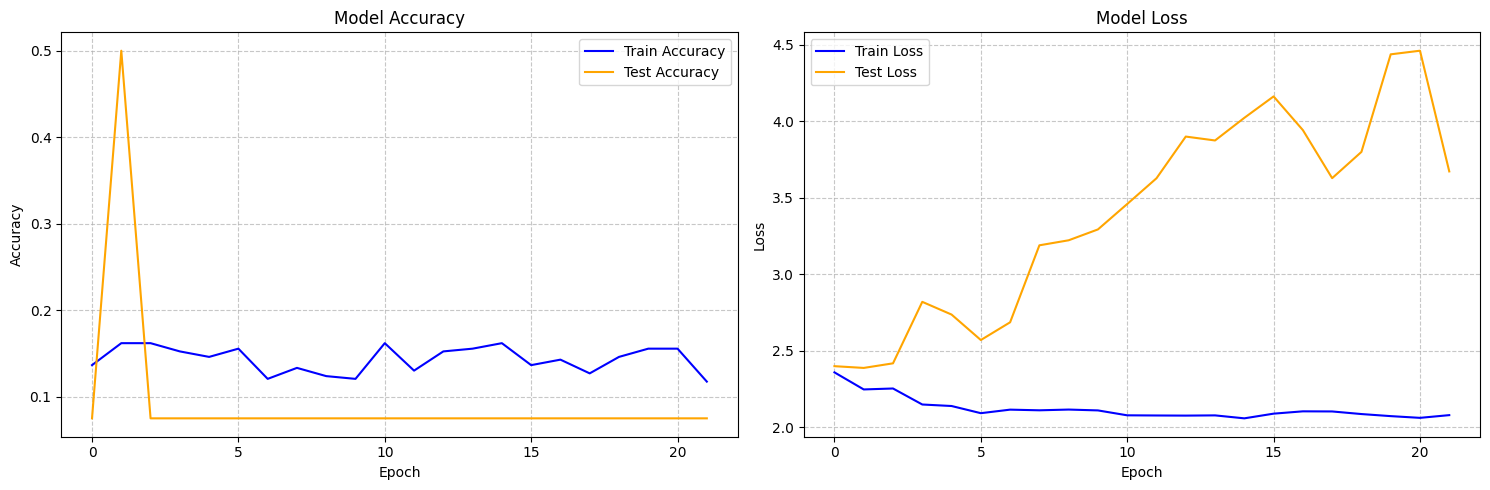

In [254]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot Accuracy
    ax1.plot(history['train_acc'], label='Train Accuracy', color='blue')
    ax1.plot(history['test_acc'], label='Test Accuracy', color='orange')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot Loss
    ax2.plot(history['train_loss'], label='Train Loss', color='blue')
    ax2.plot(history['test_loss'], label='Test Loss', color='orange')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Generate the plots!
plot_training_history(history)

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

def generate_thesis_metrics(model, test_loader, best_model_path="D:\\IDE Repo\\Dl-net\\notebook\\ssgnn\\lieai_best_ssgnn.pth"):
    # 1. Load the absolute best weights
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    
    all_preds = []
    all_labels = []
    
    print("🧠 Running final evaluation on Test Set...")
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model(data)
            # Ensure output is flattened if your model returns shape (N, C)
            preds = out.argmax(dim=1).cpu().numpy()
            labels = data.y.cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels)
            
    # Convert to numpy arrays for easier filtering
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
            
    # 2. Fix: Get only the unique classes present in the test evaluation
    unique_present_classes = np.unique(np.concatenate([all_labels, all_preds]))
    
    # Map indices to actual emotion names from your encoder
    present_target_names = [encoder.classes_[i] for i in unique_present_classes]
    
    print("\n--- Final Classification Report ---")
    # Pass labels explicitly to ensure alignment
    print(classification_report(all_labels, all_preds, 
                                labels=unique_present_classes, 
                                target_names=present_target_names))
    
    # 3. Plot the Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds, labels=unique_present_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=present_target_names, yticklabels=present_target_names)
    plt.title('LieAI: Spatial-Temporal Confusion Matrix', fontsize=14)
    plt.ylabel('True Micro-Expression', fontsize=12)
    plt.xlabel('Predicted Micro-Expression', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()